# Week 6: Fine-Tuning and Final Test Evaluation

**Project:** Automated Casting Defect Detection Using Deep Learning and Computer Vision

## Objective
Week 6 fine-tunes the best model selected in Week 5 and evaluates it once on the held-out test set. This week adds controlled fine-tuning, validation-based threshold selection, final test metrics, confidence intervals and error analysis.

## Team Contributions
| Member | Name | Role | Week 6 Contribution |
|---|---|---|---|
| 1 | Sandeep Bommagoni | Data & EDA Lead | Recreated split and protected held-out test set |
| 2 | Likith Kumar Devulapalli | Architecture / Xception Lead | Prepared selected model architecture for fine-tuning |
| 3 | Raghava Krishna Battu | Model Comparison Lead | Fine-tuned the selected model |
| 4 | Navatej Patel Cheerneni | Evaluation & XAI Lead | Completed threshold search, final metrics, CI and error analysis |
| 5 | Tharun Chinnachinnaiahgari | GitHub / Deployment Lead | Saved final metadata, summary and GitHub evidence |

In [1]:

import os, json, random, time
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, fbeta_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score
SEED=123
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.17.0


## 1. Configuration and Split
**Contributor:** Sandeep Bommagoni

In [2]:

DATASET_ROOT=Path('/kaggle/input/real-life-industrial-dataset-of-casting-product')
SELECTED_MODEL_NAME='Xception'  # Change only if Week 5 selected another model
IMAGE_SIZE=(299,299) if SELECTED_MODEL_NAME=='Xception' else (224,224)
BATCH_SIZE=24
LABEL_TO_ID={'ok_front':0,'def_front':1}; ID_TO_LABEL={0:'ok_front',1:'def_front'}
OUTPUT_DIR=Path('/kaggle/working/week6_fine_tuning_test_evaluation')
MODEL_DIR=OUTPUT_DIR/'models'; PLOT_DIR=OUTPUT_DIR/'plots'; REPORT_DIR=OUTPUT_DIR/'reports'
for d in [MODEL_DIR,PLOT_DIR,REPORT_DIR]: d.mkdir(parents=True, exist_ok=True)
SUPPORTED={'.jpg','.jpeg','.png','.bmp'}

def discover_source(root):
    pairs=[]
    for d in root.rglob('def_front'):
        if (d.parent/'ok_front').is_dir(): pairs.append(d.parent)
    if not pairs: raise FileNotFoundError('No folder pair found')
    raw=[p for p in sorted(set(pairs)) if '512' in str(p).lower()]
    return raw[0] if raw else sorted(set(pairs))[0]
source=discover_source(DATASET_ROOT)
rows=[]
for label_name,label_id in LABEL_TO_ID.items():
    for path in sorted((source/label_name).iterdir()):
        if path.is_file() and path.suffix.lower() in SUPPORTED:
            img=cv2.imread(str(path)); rows.append({'path':str(path),'filename':path.name,'label_name':label_name,'label':label_id,'readable':img is not None})
manifest=pd.DataFrame(rows); manifest=manifest[manifest.readable].reset_index(drop=True)
train_df,temp_df=train_test_split(manifest,train_size=.70,stratify=manifest.label,random_state=SEED)
val_df,test_df=train_test_split(temp_df,train_size=.50,stratify=temp_df.label,random_state=SEED)
train_df=train_df.reset_index(drop=True); val_df=val_df.reset_index(drop=True); test_df=test_df.reset_index(drop=True)
split_manifest=pd.concat([train_df.assign(split='train'),val_df.assign(split='validation'),test_df.assign(split='test')],ignore_index=True)
split_counts=split_manifest.groupby(['split','label_name']).size().reset_index(name='images')
display(split_counts)
split_manifest.to_csv(REPORT_DIR/'week6_train_validation_test_manifest.csv',index=False); split_counts.to_csv(REPORT_DIR/'week6_split_counts.csv',index=False)
weights=compute_class_weight('balanced',classes=np.array([0,1]),y=train_df.label.to_numpy()); CLASS_WEIGHTS={0:float(weights[0]),1:float(weights[1])}
with open(REPORT_DIR/'week6_class_weights.json','w') as f: json.dump(CLASS_WEIGHTS,f,indent=4)


,split,label_name,images
0,test,def_front,118
1,test,ok_front,78
2,train,def_front,546
3,train,ok_front,363
4,validation,def_front,117
5,validation,ok_front,78


## 2. Dataset Pipeline
**Contributor:** Sandeep Bommagoni

In [3]:

AUTOTUNE=tf.data.AUTOTUNE
def decode_resize(path,label):
    img=tf.io.decode_image(tf.io.read_file(path),channels=3,expand_animations=False); img.set_shape([None,None,3])
    img=tf.image.resize(img,IMAGE_SIZE,antialias=True); return tf.cast(img,tf.float32),tf.cast(label,tf.float32)
def make_ds(df,training=False):
    ds=tf.data.Dataset.from_tensor_slices((df.path.astype(str).to_numpy(),df.label.astype(np.float32).to_numpy()))
    if training: ds=ds.shuffle(len(df),seed=SEED,reshuffle_each_iteration=True)
    return ds.map(decode_resize,num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
train_ds=make_ds(train_df,True); val_ds=make_ds(val_df,False); test_ds=make_ds(test_df,False)


## 3. Build Selected Model
**Contributor:** Likith Kumar Devulapalli

In [4]:

def aug(): return keras.Sequential([layers.RandomFlip('horizontal'),layers.RandomRotation(.04),layers.RandomZoom(.08),layers.RandomContrast(.10)],name='augmentation')
def model_cls_pre(name):
    return {
        'Xception':(keras.applications.Xception,keras.applications.xception.preprocess_input),
        'MobileNetV2':(keras.applications.MobileNetV2,keras.applications.mobilenet_v2.preprocess_input),
        'EfficientNetB0':(keras.applications.EfficientNetB0,keras.applications.efficientnet.preprocess_input),
        'DenseNet121':(keras.applications.DenseNet121,keras.applications.densenet.preprocess_input),
    }[name]
def build_selected(name):
    cls,pre=model_cls_pre(name); inp=keras.Input(shape=IMAGE_SIZE+(3,),name='image'); x=aug()(inp); x=pre(x)
    try: base=cls(include_top=False,weights='imagenet',input_shape=IMAGE_SIZE+(3,),pooling='avg',name=name.lower())
    except Exception: base=cls(include_top=False,weights=None,input_shape=IMAGE_SIZE+(3,),pooling='avg',name=name.lower())
    base.trainable=False; x=base(x,training=False); x=layers.BatchNormalization()(x); x=layers.Dense(256,activation='relu')(x); x=layers.Dropout(.35)(x)
    out=layers.Dense(1,activation='sigmoid',name='probability_defective')(x); return keras.Model(inp,out,name='Week6_'+name)
model=build_selected(SELECTED_MODEL_NAME)
model.compile(optimizer=keras.optimizers.Adam(1e-3),loss='binary_crossentropy',metrics=['accuracy',keras.metrics.Precision(name='defect_precision'),keras.metrics.Recall(name='defect_recall'),keras.metrics.AUC(name='roc_auc'),keras.metrics.AUC(name='pr_auc',curve='PR')])
model.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "Week6_Xception"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                   │ (None, 299, 299, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 299, 299, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 299, 299, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 299, 299, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xception (Functional)                │ (None, 2048)                │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ probability_defective (Dense)        │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,394,473 (81.61 MB)

 Trainable params: 528,897 (2.02 MB)

 Non-trainable params: 20,865,576 (79.60 MB)

## 4. Head Training and Fine-Tuning
**Contributor:** Raghava Krishna Battu

In [5]:

head_callbacks=[keras.callbacks.ModelCheckpoint(MODEL_DIR/'week6_head_best.keras',monitor='val_pr_auc',mode='max',save_best_only=True),keras.callbacks.EarlyStopping(monitor='val_pr_auc',mode='max',patience=3,restore_best_weights=True),keras.callbacks.CSVLogger(REPORT_DIR/'week6_head_training_log.csv')]
start=time.time(); head_hist=model.fit(train_ds,validation_data=val_ds,epochs=8,class_weight=CLASS_WEIGHTS,callbacks=head_callbacks,verbose=1); head_minutes=(time.time()-start)/60
pd.DataFrame(head_hist.history).to_csv(REPORT_DIR/'week6_head_training_history.csv',index=False)
backbone=model.get_layer(SELECTED_MODEL_NAME.lower()); backbone.trainable=True
fine_tune_at=int(len(backbone.layers)*.80)
for layer in backbone.layers[:fine_tune_at]: layer.trainable=False
trainable_layers=sum(1 for layer in backbone.layers if layer.trainable)
model.compile(optimizer=keras.optimizers.Adam(1e-5),loss='binary_crossentropy',metrics=['accuracy',keras.metrics.Precision(name='defect_precision'),keras.metrics.Recall(name='defect_recall'),keras.metrics.AUC(name='roc_auc'),keras.metrics.AUC(name='pr_auc',curve='PR')])
fine_callbacks=[keras.callbacks.ModelCheckpoint(MODEL_DIR/'week6_fine_tuned_best.keras',monitor='val_pr_auc',mode='max',save_best_only=True),keras.callbacks.EarlyStopping(monitor='val_pr_auc',mode='max',patience=3,restore_best_weights=True),keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=.3,patience=2,min_lr=1e-7),keras.callbacks.CSVLogger(REPORT_DIR/'week6_fine_tuning_log.csv')]
start=time.time(); fine_hist=model.fit(train_ds,validation_data=val_ds,epochs=8,class_weight=CLASS_WEIGHTS,callbacks=fine_callbacks,verbose=1); fine_minutes=(time.time()-start)/60
pd.DataFrame(fine_hist.history).to_csv(REPORT_DIR/'week6_fine_tuning_history.csv',index=False)
print('Trainable backbone layers:',trainable_layers)


Epoch 1/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 262ms/step - accuracy: 0.8018 - defect_precision: 0.8753 - defect_recall: 0.7526 - loss: 0.4935 - pr_auc: 0.9143 - roc_auc: 0.8782 - val_accuracy: 0.6513 - val_defect_precision: 0.6324 - val_defect_recall: 1.0000 - val_loss: 0.4999 - val_pr_auc: 0.9810 - val_roc_auc: 0.9687
Epoch 2/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - accuracy: 0.9654 - defect_precision: 0.9822 - defect_recall: 0.9597 - loss: 0.0925 - pr_auc: 0.9963 - roc_auc: 0.9938 - val_accuracy: 0.7487 - val_defect_precision: 0.7048 - val_defect_recall: 1.0000 - val_loss: 0.4151 - val_pr_auc: 0.9971 - val_roc_auc: 0.9954
Epoch 3/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - accuracy: 0.9788 - defect_precision: 0.9769 - defect_recall: 0.9879 - loss: 0.0559 - pr_auc: 0.9988 - roc_auc: 0.9981 - val_accuracy: 0.8974 - val_defect_precision: 0.8540 - val_defect_recall: 1.0000 - val_loss: 0.2661 - val_pr_auc: 0.9992 - val_roc_auc: 0.9988
Epoch 4/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - a

## 5. Threshold Selection and Final Test Evaluation
**Contributor:** Navatej Patel Cheerneni

{'selected_model': 'Xception',
 'threshold': 0.24999999999999992,
 'accuracy': 0.9897959183673469,
 'balanced_accuracy': 0.9915254237288136,
 'defect_precision': 1.0,
 'defect_recall': 0.9830508474576272,
 'f1_defect': 0.9914529914529915,
 'f2_defect': 0.9863945578231292,
 'roc_auc': 0.9992394611038679,
 'pr_auc': 0.9995254237288136}

,precision,recall,f1-score,support
ok_front,0.975000,1.000000,0.987342,78.000000
def_front,1.000000,0.983051,0.991453,118.000000
accuracy,0.989796,0.989796,0.989796,0.989796
macro avg,0.987500,0.991525,0.989397,196.000000
weighted avg,0.990051,0.989796,0.989817,196.000000


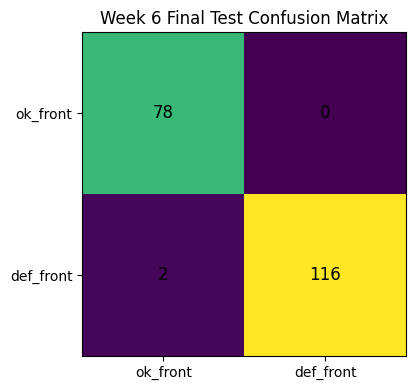

In [6]:

def labels(ds): return np.concatenate([y.numpy().reshape(-1) for _,y in ds]).astype(int)
def probs(model,ds): return model.predict(ds,verbose=0).reshape(-1)
y_val=labels(val_ds); val_p=probs(model,val_ds)
rows=[]
for th in np.arange(.10,.91,.01):
    pred=(val_p>=th).astype(int)
    rows.append({'threshold':float(th),'balanced_accuracy':float(balanced_accuracy_score(y_val,pred)),'defect_recall':float(recall_score(y_val,pred,pos_label=1,zero_division=0)),'f2_defect':float(fbeta_score(y_val,pred,beta=2,pos_label=1,zero_division=0))})
th_df=pd.DataFrame(rows).sort_values(['f2_defect','defect_recall','balanced_accuracy'],ascending=False).reset_index(drop=True)
BEST_THRESHOLD=float(th_df.loc[0,'threshold']); th_df.to_csv(REPORT_DIR/'week6_validation_threshold_search.csv',index=False)
with open(REPORT_DIR/'week6_selected_threshold.json','w') as f: json.dump({'selected_threshold':BEST_THRESHOLD},f,indent=4)
y_test=labels(test_ds); test_p=probs(model,test_ds); test_pred=(test_p>=BEST_THRESHOLD).astype(int)
test_metrics={'selected_model':SELECTED_MODEL_NAME,'threshold':BEST_THRESHOLD,'accuracy':float(accuracy_score(y_test,test_pred)),'balanced_accuracy':float(balanced_accuracy_score(y_test,test_pred)),'defect_precision':float(precision_score(y_test,test_pred,pos_label=1,zero_division=0)),'defect_recall':float(recall_score(y_test,test_pred,pos_label=1,zero_division=0)),'f1_defect':float(f1_score(y_test,test_pred,pos_label=1,zero_division=0)),'f2_defect':float(fbeta_score(y_test,test_pred,beta=2,pos_label=1,zero_division=0)),'roc_auc':float(roc_auc_score(y_test,test_p)),'pr_auc':float(average_precision_score(y_test,test_p))}
with open(REPORT_DIR/'week6_final_test_metrics.json','w') as f: json.dump(test_metrics,f,indent=4)
report_df=pd.DataFrame(classification_report(y_test,test_pred,target_names=['ok_front','def_front'],output_dict=True,zero_division=0)).transpose(); report_df.to_csv(REPORT_DIR/'week6_final_classification_report.csv')
cm=confusion_matrix(y_test,test_pred,labels=[0,1]); pd.DataFrame(cm,index=['Actual ok_front','Actual def_front'],columns=['Pred ok_front','Pred def_front']).to_csv(REPORT_DIR/'week6_final_confusion_matrix.csv')
display(test_metrics); display(report_df)
fig,ax=plt.subplots(figsize=(5,4)); ax.imshow(cm); ax.set_title('Week 6 Final Test Confusion Matrix'); ax.set_xticks([0,1]); ax.set_yticks([0,1]); ax.set_xticklabels(['ok_front','def_front']); ax.set_yticklabels(['ok_front','def_front'])
for i in range(2):
    for j in range(2): ax.text(j,i,cm[i,j],ha='center',va='center',fontsize=12)
plt.tight_layout(); plt.savefig(PLOT_DIR/'week6_final_confusion_matrix.png',dpi=160); plt.show()


## 6. Confidence Intervals and Error Analysis
**Contributor:** Navatej Patel Cheerneni

In [7]:

rng=np.random.default_rng(SEED); boot=[]
for _ in range(500):
    idx=rng.integers(0,len(y_test),len(y_test)); yb=y_test[idx]; pb=test_p[idx]; pr=(pb>=BEST_THRESHOLD).astype(int)
    if len(np.unique(yb))<2: continue
    boot.append({'accuracy':accuracy_score(yb,pr),'defect_recall':recall_score(yb,pr,pos_label=1,zero_division=0),'defect_precision':precision_score(yb,pr,pos_label=1,zero_division=0),'roc_auc':roc_auc_score(yb,pb),'pr_auc':average_precision_score(yb,pb)})
boot_df=pd.DataFrame(boot); ci=[]
for metric in boot_df.columns:
    ci.append({'metric':metric,'lower_95':float(np.percentile(boot_df[metric],2.5)),'upper_95':float(np.percentile(boot_df[metric],97.5))})
ci_df=pd.DataFrame(ci); ci_df.to_csv(REPORT_DIR/'week6_bootstrap_confidence_intervals.csv',index=False); display(ci_df)
err=test_df.copy(); err['true_label']=y_test; err['predicted_label']=test_pred; err['defect_probability']=test_p; err['correct']=err.true_label==err.predicted_label
err['true_label_name']=err.true_label.map(ID_TO_LABEL); err['predicted_label_name']=err.predicted_label.map(ID_TO_LABEL)
err.to_csv(REPORT_DIR/'week6_test_predictions.csv',index=False); err[~err.correct].to_csv(REPORT_DIR/'week6_misclassified_test_images.csv',index=False)
print('Misclassified test images:', int((~err.correct).sum()))


,metric,lower_95,upper_95
0,accuracy,0.974490,1.0
1,defect_recall,0.958333,1.0
2,defect_precision,1.000000,1.0
3,roc_auc,0.997043,1.0
4,pr_auc,0.997979,1.0


Misclassified test images: 2


## 7. Save Final Model
**Contributor:** Tharun Chinnachinnaiahgari

In [8]:

model.save(MODEL_DIR/'week6_final_fine_tuned_model.keras')
metadata={'week':'Week 6','selected_model':SELECTED_MODEL_NAME,'image_size':IMAGE_SIZE,'class_weights':CLASS_WEIGHTS,'selected_threshold':BEST_THRESHOLD,'test_metrics':test_metrics,'trainable_backbone_layers':int(trainable_layers)}
with open(REPORT_DIR/'week6_final_model_metadata.json','w') as f: json.dump(metadata,f,indent=4)
print('Final model metadata saved.')


Final model metadata saved.


## 8. Week 6 Findings
Week 6 provides final technical evidence: fine-tuned model, validation-based threshold, held-out test results, confidence intervals and error analysis. Week 7 will focus on Grad-CAM explainability and responsible AI.